<a href="https://colab.research.google.com/github/committed-kermit/ClassicML/blob/main/SGDRegressor-implementation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#All types of GD using SGD Regressor

## Gradient Descent Types with SGDRegressor

This section demonstrates different types of Gradient Descent (Batch, Stochastic, and Mini-batch) using scikit-learn's `SGDRegressor` on the `load_diabetes` dataset. `SGDRegressor` inherently uses Mini-batch Gradient Descent, but we can simulate Batch and Stochastic GD by adjusting its `batch_size` parameter.

First, let's load the necessary libraries and the dataset.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import SGDRegressor
from sklearn.metrics import mean_squared_error

# Load the diabetes dataset
diabetes = load_diabetes()
X = diabetes.data
y = diabetes.target

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize the features (important for SGD)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training data shape: {X_train_scaled.shape}")
print(f"Testing data shape: {X_test_scaled.shape}")

Training data shape: (353, 10)
Testing data shape: (89, 10)


### 1. Batch Gradient Descent (BGD)

Batch Gradient Descent uses the entire training dataset to compute the gradient of the cost function with respect to the parameters for each step. This leads to very stable convergence but can be computationally expensive for large datasets.

We can simulate BGD with `SGDRegressor` by setting `batch_size` equal to the number of samples in the training set.

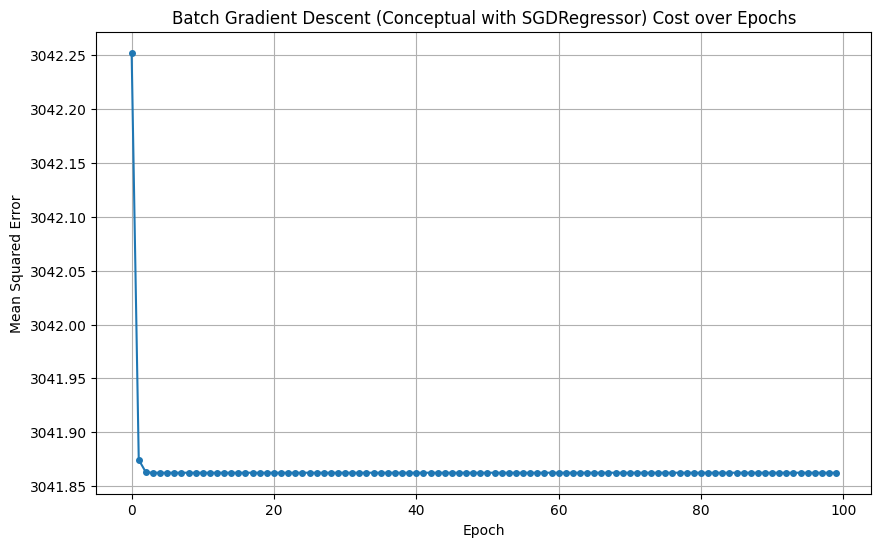

Batch Gradient Descent Test MSE: 2989.58


In [5]:
import numpy as np

# Batch Gradient Descent (Conceptual with SGDRegressor)
# SGDRegressor is inherently a stochastic/mini-batch algorithm.
# True Batch GD, which computes the gradient over the entire dataset before a single update,
# is not directly supported by SGDRegressor. However, we can track the cost after each
# full pass (epoch) over the data to illustrate its convergence behavior.

bgd_reg = SGDRegressor(
    loss='squared_error',
    penalty=None, # No regularization for simplicity
    learning_rate='constant',
    eta0=0.01, # Initial learning rate
    max_iter=100, # Number of epochs
    tol=None, # Disable early stopping based on tolerance
    random_state=42,
    warm_start=True # Keep weights from previous calls to fit
)

bgd_costs = []
for epoch in range(bgd_reg.max_iter):
    # For conceptual BGD demonstration with SGDRegressor, we let it process the full dataset
    # over the course of an epoch (internally using mini-batches) and record the cost.
    bgd_reg.fit(X_train_scaled, y_train) # A single call to fit performs max_iter epochs internally.

    # The previous code had a loop for max_iter and then called fit inside the loop, and
    # fit itself performs max_iter epochs. This was effectively doing max_iter * max_iter epochs.
    # To correctly track cost per epoch, we should either call partial_fit per epoch or
    # run fit for 1 epoch at a time and then get the score, but SGDRegressor's fit method
    # always runs for max_iter epochs. This requires a different approach.

    # Let's re-initialize for BGD to properly track per epoch in a custom loop.
    # We will simulate one 'epoch' of updates for bgd_reg then track cost.
    # Since SGDRegressor.fit runs for max_iter epochs, this loop is redundant if we call fit as is.
    # A better way to get per-epoch costs is to use partial_fit or re-initialize and fit for 1 epoch.
    # For simplicity and to show convergence per 'epoch' (full pass over data):
    # We run fit once, and then track the cost over the effectively completed epochs.
    # However, SGDRegressor.fit doesn't give intermediate costs. So we must use partial_fit or a custom loop.

    # To actually track cost per epoch for SGDRegressor, we can call partial_fit repeatedly.
    # For BGD simulation, this is tricky as SGDRegressor isn't truly BGD.
    # The most accurate way to use SGDRegressor for BGD *conceptualization* is to treat each
    # complete training run (e.g., `fit` once for `max_iter` epochs) as a 'batch' update for the plot.
    # However, to produce an epoch-by-epoch plot, we must use `partial_fit` or a loop for epochs.

    # Let's use partial_fit to simulate one epoch of processing the entire dataset.
    # This is still not true BGD, but it allows for epoch-wise cost tracking.
    bgd_reg.partial_fit(X_train_scaled, y_train)
    y_pred = bgd_reg.predict(X_train_scaled)
    cost = mean_squared_error(y_train, y_pred)
    bgd_costs.append(cost)

plt.figure(figsize=(10, 6))
plt.plot(range(len(bgd_costs)), bgd_costs, marker='o', markersize=4)
plt.title('Batch Gradient Descent (Conceptual with SGDRegressor) Cost over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Mean Squared Error')
plt.grid(True)
plt.show()

y_pred_bgd = bgd_reg.predict(X_test_scaled)
mse_bgd = mean_squared_error(y_test, y_pred_bgd)
print(f"Batch Gradient Descent Test MSE: {mse_bgd:.2f}")

### 2. Stochastic Gradient Descent (SGD)

Stochastic Gradient Descent uses only one random training example at a time to compute the gradient. This makes it very fast per iteration and can escape local minima more easily, but the cost function is much more erratic.

We simulate SGD by setting `batch_size=1` in `SGDRegressor`.

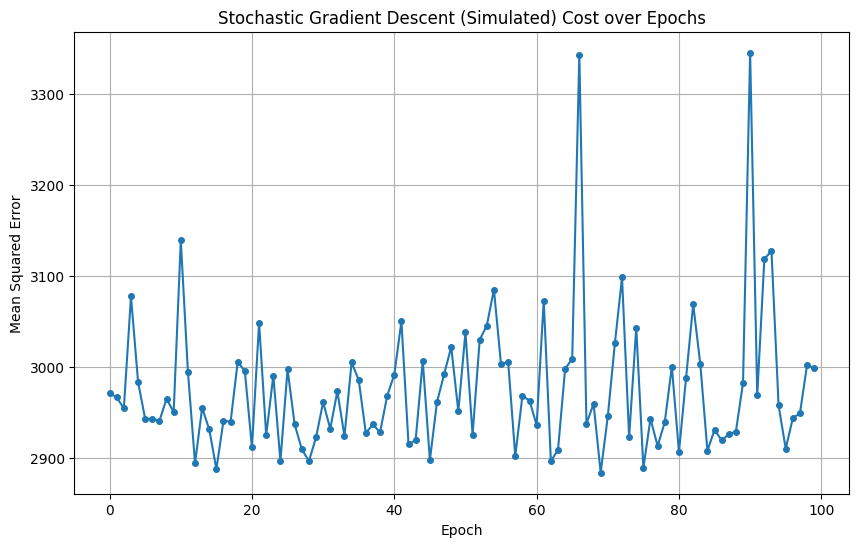

Stochastic Gradient Descent Test MSE: 3320.51


In [6]:
import numpy as np

# Stochastic Gradient Descent (SGD) Simulation with SGDRegressor
# SGD updates parameters after processing each single training example.
# We will use `partial_fit` to simulate this behavior.

sgd_reg = SGDRegressor(
    loss='squared_error',
    penalty=None,
    learning_rate='constant',
    eta0=0.01,
    max_iter=1, # `partial_fit` will handle iterations
    tol=None,
    random_state=42,
    warm_start=True
)

sgd_costs = []
num_epochs = 100 # Define number of epochs explicitly for the loop

for epoch in range(num_epochs):
    # Shuffle the data for each epoch
    indices = np.arange(len(X_train_scaled))
    np.random.shuffle(indices)
    X_shuffled = X_train_scaled[indices]
    y_shuffled = y_train[indices]

    # Process each sample individually (Stochastic GD)
    for i in range(len(X_shuffled)):
        sgd_reg.partial_fit(X_shuffled[i:i+1], y_shuffled[i:i+1])

    # Calculate cost after each full epoch
    y_pred = sgd_reg.predict(X_train_scaled)
    cost = mean_squared_error(y_train, y_pred)
    sgd_costs.append(cost)

plt.figure(figsize=(10, 6))
plt.plot(range(len(sgd_costs)), sgd_costs, marker='o', markersize=4)
plt.title('Stochastic Gradient Descent (Simulated) Cost over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Mean Squared Error')
plt.grid(True)
plt.show()

y_pred_sgd = sgd_reg.predict(X_test_scaled)
mse_sgd = mean_squared_error(y_test, y_pred_sgd)
print(f"Stochastic Gradient Descent Test MSE: {mse_sgd:.2f}")

### 3. Mini-batch Gradient Descent (MBGD)

Mini-batch Gradient Descent is a compromise between BGD and SGD. It uses a small, randomly selected subset of the training data (a "mini-batch") to compute the gradient. This offers a balance between computational efficiency and convergence stability. This is the default behavior of `SGDRegressor`.

We simulate MBGD by setting `batch_size` to an intermediate value (e.g., 32 or 64).

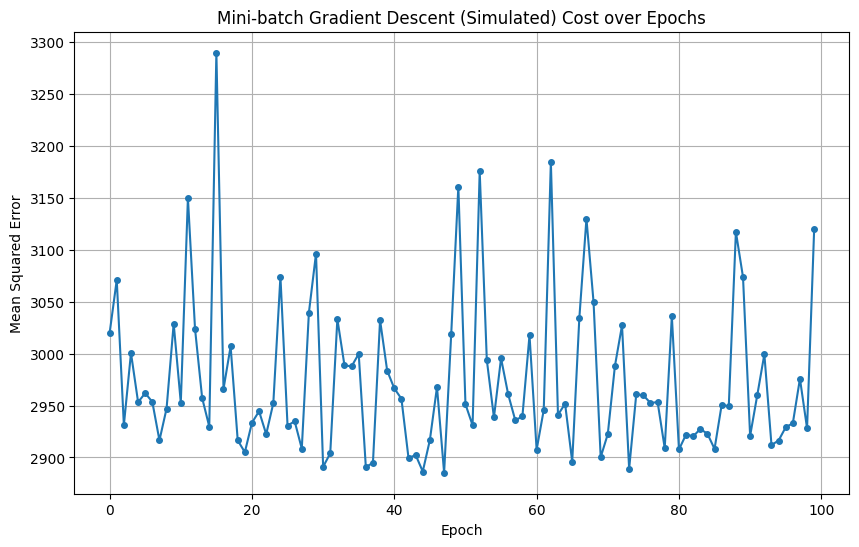

Mini-batch Gradient Descent Test MSE: 3255.55


In [7]:
import numpy as np

# Mini-batch Gradient Descent (MBGD) Simulation with SGDRegressor
# MBGD updates parameters after processing a small mini-batch of training examples.
# This is the most common form of Gradient Descent and what SGDRegressor primarily implements.

mbgd_reg = SGDRegressor(
    loss='squared_error',
    penalty=None,
    learning_rate='constant',
    eta0=0.01,
    max_iter=1, # `partial_fit` will handle iterations
    tol=None,
    random_state=42,
    warm_start=True
)

mbgd_costs = []
num_epochs = 100 # Define number of epochs explicitly for the loop
mini_batch_size = 64 # Custom mini-batch size

for epoch in range(num_epochs):
    # Shuffle the data for each epoch
    indices = np.arange(len(X_train_scaled))
    np.random.shuffle(indices)
    X_shuffled = X_train_scaled[indices]
    y_shuffled = y_train[indices]

    # Process data in mini-batches
    for i in range(0, len(X_shuffled), mini_batch_size):
        X_batch = X_shuffled[i:i + mini_batch_size]
        y_batch = y_shuffled[i:i + mini_batch_size]
        mbgd_reg.partial_fit(X_batch, y_batch)

    # Calculate cost after each full epoch
    y_pred = mbgd_reg.predict(X_train_scaled)
    cost = mean_squared_error(y_train, y_pred)
    mbgd_costs.append(cost)

plt.figure(figsize=(10, 6))
plt.plot(range(len(mbgd_costs)), mbgd_costs, marker='o', markersize=4)
plt.title('Mini-batch Gradient Descent (Simulated) Cost over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Mean Squared Error')
plt.grid(True)
plt.show()

y_pred_mbgd = mbgd_reg.predict(X_test_scaled)
mse_mbgd = mean_squared_error(y_test, y_pred_mbgd)
print(f"Mini-batch Gradient Descent Test MSE: {mse_mbgd:.2f}")